CELL 0 — Environment Setup (RUN ONCE)


In [ ]:
# ==============================
# CELL 0: INSTALL DEPENDENCIES
# ==============================
!pip install -q transformers datasets evaluate kagglehub bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 15.5 MB/s eta 0:00:00


CELL 1 — Imports & Global Config

In [ ]:
# ==============================
# CELL 1: IMPORTS & CONFIG
# ==============================
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)

import evaluate
import kagglehub

CELL 2 — Dataset Download & Load (FIXED)

In [ ]:
# ==============================
# CELL 2: LOAD DATASET
# ==============================
DATA_DIR = kagglehub.dataset_download(
    "dhivyeshrk/diseases-and-symptoms-dataset"
)

print("Files:", os.listdir(DATA_DIR))

CSV_PATH = os.path.join(
    DATA_DIR,
    "Final_Augmented_dataset_Diseases_and_Symptoms.csv"
)

df = pd.read_csv(CSV_PATH, on_bad_lines="skip")
df.dropna(inplace=True)

# print("Dataset shape:", df.shape)
# df.head()

Using Colab cache for faster access to the 'diseases-and-symptoms-dataset' dataset.
Files: ['Final_Augmented_dataset_Diseases_and_Symptoms.csv', '.nfs000000007015b5d4000002a1']


In [ ]:
# ==============================
# CELL 3: 5 UNIQUE DISEASES (AGGREGATED & TRANSPOSED)
# ==============================

DISEASE_COL = "diseases"

# Symptom columns
symptom_cols = [c for c in df.columns if c != DISEASE_COL]

# Select 5 unique diseases
five_diseases = df[DISEASE_COL].unique()[:5]

# Filter
filtered_df = df[df[DISEASE_COL].isin(five_diseases)]

# Aggregate so each disease appears ONLY ONCE
# (max = symptom present if it appears at least once)
agg_df = (
    filtered_df
    .groupby(DISEASE_COL)[symptom_cols]
    .max()
)

# Transpose for visualization
viz_df = agg_df.T

# Display
viz_df

diseases,cryptorchidism,panic disorder,poisoning due to ethylene glycol,turner syndrome,vocal cord polyp
anxiety and nervousness,0,1,0,0,0
depression,0,1,1,1,0
shortness of breath,0,1,0,0,0
depressive or psychotic symptoms,0,1,1,0,0
sharp chest pain,0,0,0,0,0
...,...,...,...,...,...
hip weakness,0,0,0,0,0
back swelling,0,0,0,0,0
ankle stiffness or tightness,0,0,0,0,0
ankle weakness,0,0,0,0,0


In [ ]:
# ==============================
# CELL: UNIQUE DISEASES & SYMPTOMS COUNT
# ==============================

DISEASE_COL = "diseases"

# Unique diseases count
unique_diseases_count = df[DISEASE_COL].nunique()

# Total unique symptoms count (all columns except disease)
unique_symptoms_count = df.shape[1] - 1

print(f"Total Unique Diseases: {unique_diseases_count}")
print(f"Total Unique Symptoms: {unique_symptoms_count}")

Total Unique Diseases: 773
Total Unique Symptoms: 377


In [ ]:
# ==============================
# CELL: TOTAL SAMPLE COUNT
# ==============================

total_samples = df.shape[0]

print(f"Total Samples (Rows): {total_samples}")

Total Samples (Rows): 246945


CELL 3 — Identify Label & Symptom Columns (SAFE)

In [ ]:
# ==============================
# CELL 3: IDENTIFY COLUMNS
# ==============================
label_candidates = [c for c in df.columns if "disease" in c.lower()]
LABEL_COL = label_candidates[0] if label_candidates else df.columns[0]

symptom_cols = [c for c in df.columns if c != LABEL_COL]

print("Label column:", LABEL_COL)
print("Number of symptoms:", len(symptom_cols))

Label column: diseases
Number of symptoms: 377


CELL 4 — One-Hot → Text Conversion (CRITICAL FIX)

In [ ]:
# ==============================
# CELL 4: SYMPTOM TEXT CREATION
# ==============================
def row_to_text(row):
    active = [
        s.replace("_", " ")
        for s in symptom_cols
        if row[s] == 1
    ]
    return ", ".join(active) if active else "no specific symptoms"

df["symptoms_text"] = df.apply(row_to_text, axis=1)
df[["symptoms_text", LABEL_COL]].head()

,symptoms_text,diseases
0,"anxiety and nervousness, shortness of breath, ...",panic disorder
1,"shortness of breath, depressive or psychotic s...",panic disorder
2,"anxiety and nervousness, depression, shortness...",panic disorder
3,"anxiety and nervousness, depressive or psychot...",panic disorder
4,"anxiety and nervousness, depression, insomnia,...",panic disorder


CELL 5 — Class Filtering (VERY IMPORTANT)

In [ ]:
# ==============================
# CELL 5: FILTER RARE DISEASES
# ==============================
MIN_SAMPLES = 10

counts = df[LABEL_COL].value_counts()
valid_labels = counts[counts >= MIN_SAMPLES].index

df = df[df[LABEL_COL].isin(valid_labels)].reset_index(drop=True)

print("Diseases:", df[LABEL_COL].nunique())
print("Samples:", len(df))

Diseases: 677
Samples: 246512


CELL 6 — Label Encoding (FIXED & SINGLE SOURCE)

In [ ]:
# ==============================
# CELL 6: LABEL ENCODING
# ==============================
le = LabelEncoder()
df["label"] = le.fit_transform(df[LABEL_COL])

NUM_LABELS = df["label"].nunique()
print("Encoded diseases:", NUM_LABELS)

joblib.dump(le, "label_encoder.pkl")

Encoded diseases: 677


['label_encoder.pkl']

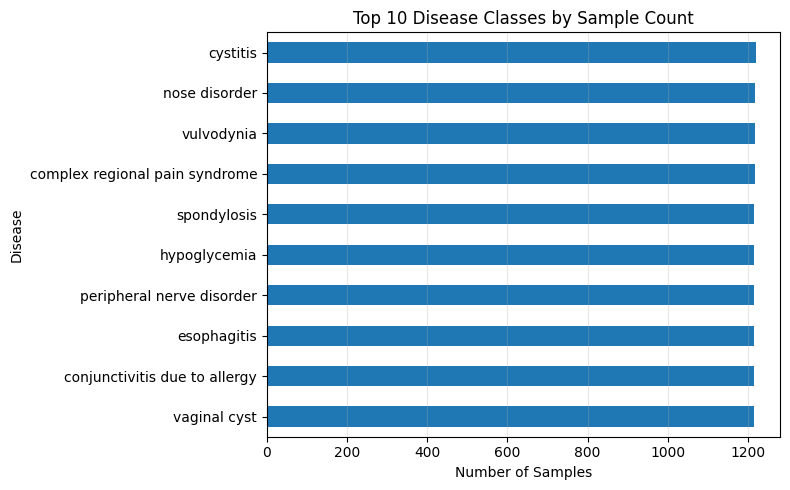

In [ ]:
# ==============================
# CELL V1: DISEASE CLASS DISTRIBUTION (HORIZONTAL)
# ==============================

plt.figure(figsize=(8, 5))

df[LABEL_COL].value_counts().head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Disease Classes by Sample Count")
plt.xlabel("Number of Samples")
plt.ylabel("Disease")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


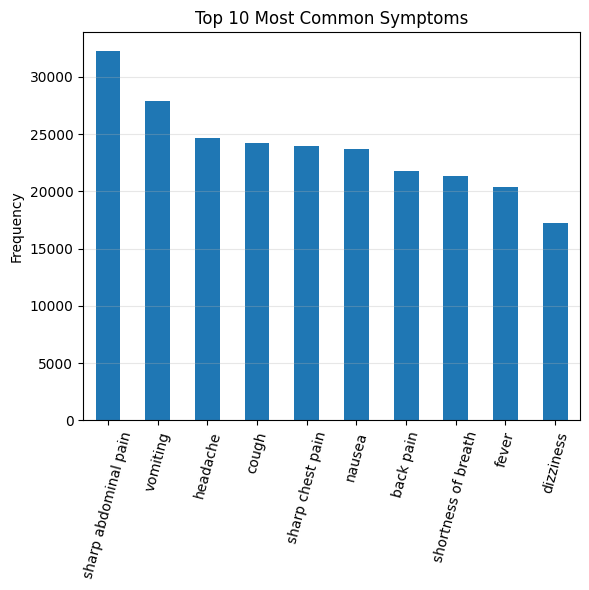

In [ ]:
# ==============================
# CELL V2: SYMPTOM FREQUENCY
# ==============================

symptom_freq = df[symptom_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 6))
symptom_freq.head(10).plot(kind="bar")
plt.title("Top 10 Most Common Symptoms")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

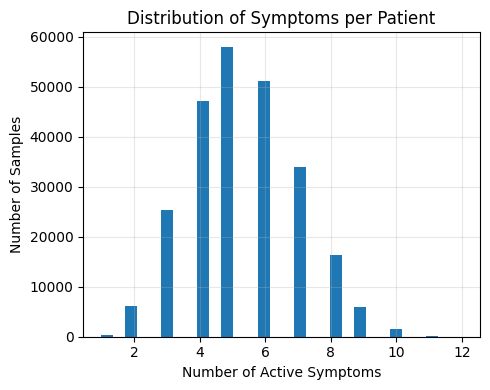

In [ ]:
# ==============================
# CELL V3: SYMPTOMS PER SAMPLE
# ==============================

symptom_counts = df[symptom_cols].sum(axis=1)

plt.figure(figsize=(5, 4))
plt.hist(symptom_counts, bins=30)
plt.xlabel("Number of Active Symptoms")
plt.ylabel("Number of Samples")
plt.title("Distribution of Symptoms per Patient")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

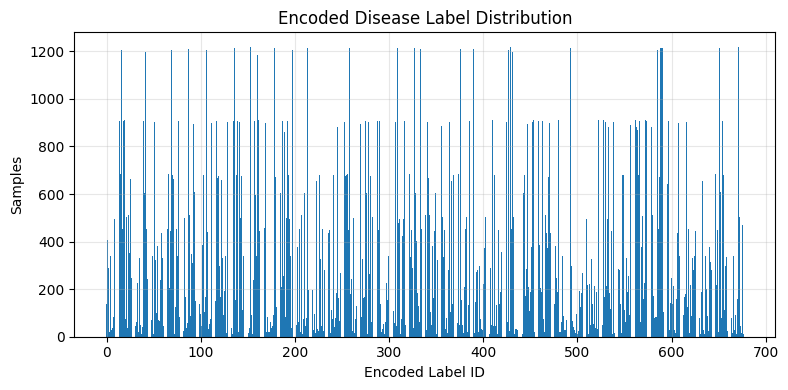

In [ ]:
# ==============================
# CELL V5: ENCODED LABEL BALANCE
# ==============================

encoded_counts = pd.Series(df["label"]).value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(encoded_counts.index, encoded_counts.values)
plt.xlabel("Encoded Label ID")
plt.ylabel("Samples")
plt.title("Encoded Disease Label Distribution")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


CELL 7 — Train / Val / Test Split (CORRECT)

In [ ]:
# ==============================
# CELL 7: TRAIN / VAL / TEST SPLIT
# ==============================
X = df["symptoms_text"].values
y = df["label"].values

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.5,
    stratify=y_tmp,
    random_state=42
)

train_ds = Dataset.from_dict({"text": X_train, "label": y_train})
val_ds   = Dataset.from_dict({"text": X_val,   "label": y_val})
test_ds  = Dataset.from_dict({"text": X_test,  "label": y_test})

print("Train data :",len(train_ds), " || Validation data :",len(val_ds)," || Test data :",len(test_ds))

Train data : 197209  || Validation data : 24651  || Test data : 24652


CELL 8 — SAVE SYMPTOM VOCAB

In [ ]:
# ==============================
# CELL 8: SAVE SYMPTOMS LIST
# ==============================
symptoms_list = [s.replace("_", " ").lower() for s in symptom_cols]
joblib.dump(symptoms_list, "symptoms_list.pkl")

print("Saved symptoms:", len(symptoms_list))

Saved symptoms: 377


CELL 9: TOKENIZER & DATA COLLATOR

In [ ]:
checkpoint = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=128
    )

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer)

print("✅ Tokenization complete")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/197209 [00:00<?, ? examples/s]

Map:   0%|          | 0/24651 [00:00<?, ? examples/s]

Map:   0%|          | 0/24652 [00:00<?, ? examples/s]

✅ Tokenization complete


CELL 10: MODEL INITIALIZATION (FP16 SAFE)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=NUM_LABELS
).to(device)

print("Using device:", device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


CELL 11: METRICS (ACCURACY + MACRO F1)

In [ ]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"]
    }

CELL 12: TRAINING ARGUMENTS

In [ ]:
training_args = TrainingArguments(
    output_dir="./checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate = 1.5e-5,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    weight_decay=0.02,
    warmup_ratio=0.15,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    label_smoothing_factor=0.1,
)

CELL 13: TRAINER + EARLY STOPPING

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.311500,2.202622,0.699972,0.382778
2,1.531900,1.470952,0.837816,0.699154
3,1.396000,1.406479,0.848160,0.773272
4,1.415300,1.372465,0.855259,0.820661
5,1.355100,1.362402,0.856760,0.836125
6,1.311200,1.351285,0.857491,0.840740
7,1.347800,1.347374,0.857409,0.848992
8,1.322800,1.346840,0.856882,0.848891


TrainOutput(global_step=98608, training_loss=1.8238344085829687, metrics={'train_runtime': 4464.1155, 'train_samples_per_second': 441.765, 'train_steps_per_second': 27.611, 'total_flos': 1.5290203585489014e+16, 'train_loss': 1.8238344085829687, 'epoch': 8.0})

CELL 14: TRAINING CURVES (LOSS / F1)

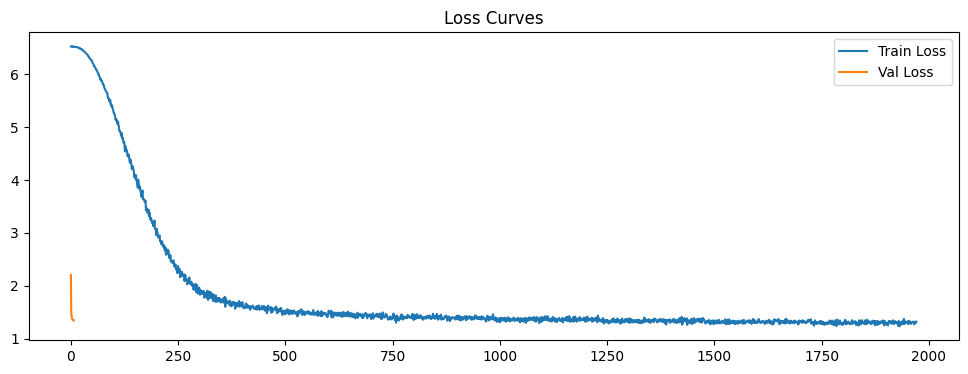

In [ ]:
logs = trainer.state.log_history

epochs, train_loss, val_loss, val_f1 = [], [], [], []

for log in logs:
    if "epoch" in log:
        epochs.append(log["epoch"])
        if "loss" in log:
            train_loss.append(log["loss"])
        if "eval_loss" in log:
            val_loss.append(log["eval_loss"])
        if "eval_f1" in log:
            val_f1.append(log["eval_f1"])

plt.figure(figsize=(12,4))
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.legend(); plt.title("Loss Curves"); plt.show()

CELL 14a: TRAIN / VAL / TEST ACCURACY CURVE

Final Train Accuracy: 88.23%
Final Test Accuracy : 85.55%


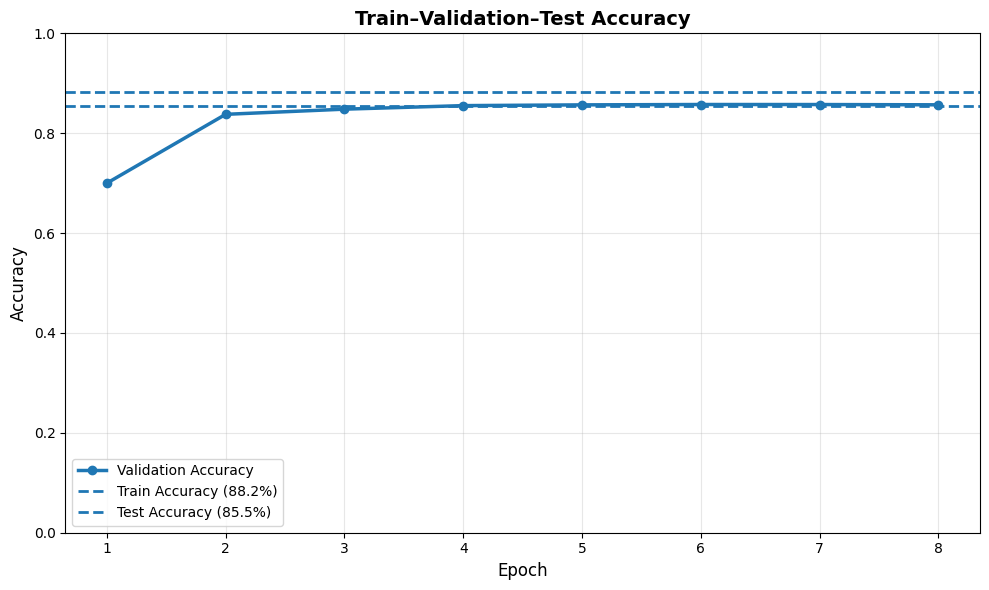

✅ Accuracy curve saved as 'accuracy_curve_train_val_test.png'


In [ ]:
# ==============================
# CELL 14a: ACCURACY CURVES
# ==============================

# ---- 1. Extract validation accuracy per epoch ----
log_history = trainer.state.log_history

epochs = []
val_acc = []

for log in log_history:
    if "epoch" in log and "eval_accuracy" in log:
        epochs.append(log["epoch"])
        val_acc.append(log["eval_accuracy"])

# ---- 2. Compute FINAL train & test accuracy ----
train_metrics = trainer.evaluate(train_ds)
test_metrics  = trainer.evaluate(test_ds)

train_acc = train_metrics["eval_accuracy"]
test_acc  = test_metrics["eval_accuracy"]

print(f"Final Train Accuracy: {train_acc*100:.2f}%")
print(f"Final Test Accuracy : {test_acc*100:.2f}%")

# ---- 3. Plot ----
plt.figure(figsize=(10, 6))

# Validation accuracy curve
plt.plot(
    epochs,
    val_acc,
    marker="o",
    linewidth=2.5,
    label="Validation Accuracy"
)

# Train & test accuracy as reference lines
plt.axhline(
    y=train_acc,
    linestyle="--",
    linewidth=2,
    label=f"Train Accuracy ({train_acc*100:.1f}%)"
)

plt.axhline(
    y=test_acc,
    linestyle="--",
    linewidth=2,
    label=f"Test Accuracy ({test_acc*100:.1f}%)"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Train–Validation–Test Accuracy", fontsize=14, fontweight="bold")
plt.ylim(0.0, 1.0)
plt.grid(alpha=0.3)
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig("accuracy_curve_train_val_test.png", dpi=300)
plt.show()

print("✅ Accuracy curve saved as 'accuracy_curve_train_val_test.png'")

CELL 14B : OVERFITTING DIAGNOSTICS

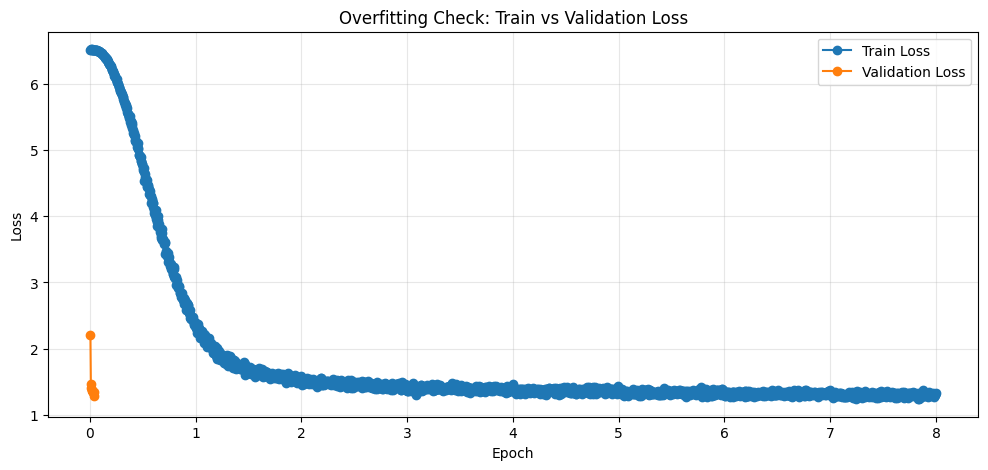

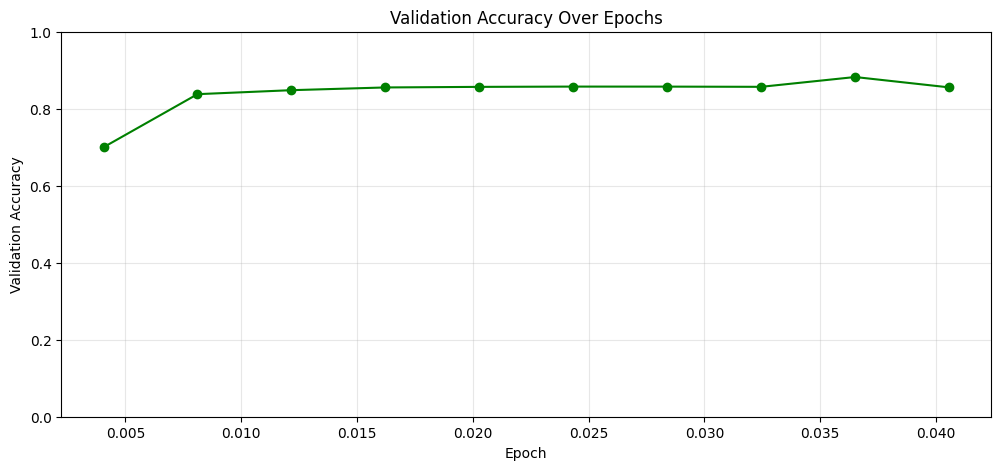

🔍 Interpretation:
- Train loss ↓ + Val loss ↑  → Overfitting
- Both losses ↓            → Good generalization
- Val accuracy plateau     → Stop training earlier


In [ ]:
# ====================================
# CELL 14B : OVERFITTING DIAGNOSTICS
# ====================================

log_history = trainer.state.log_history

epochs = []
train_loss = []
val_loss = []
val_acc = []

for log in log_history:
    if "epoch" in log:
        if "loss" in log:
            train_loss.append(log["loss"])
            epochs.append(log["epoch"])
        if "eval_loss" in log:
            val_loss.append(log["eval_loss"])
        if "eval_accuracy" in log:
            val_acc.append(log["eval_accuracy"])

# ---- Plot Loss Gap ----
plt.figure(figsize=(12, 5))
plt.plot(epochs[:len(train_loss)], train_loss, marker="o", label="Train Loss")
plt.plot(epochs[:len(val_loss)], val_loss, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overfitting Check: Train vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---- Plot Validation Accuracy ----
plt.figure(figsize=(12, 5))
plt.plot(epochs[:len(val_acc)], val_acc, marker="o", color="green")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

# ---- Interpretation Hint ----
print("🔍 Interpretation:")
print("- Train loss ↓ + Val loss ↑  → Overfitting")
print("- Both losses ↓            → Good generalization")
print("- Val accuracy plateau     → Stop training earlier")

CELL 15: CONFUSION MATRIX (TOP 20 — FIXED)

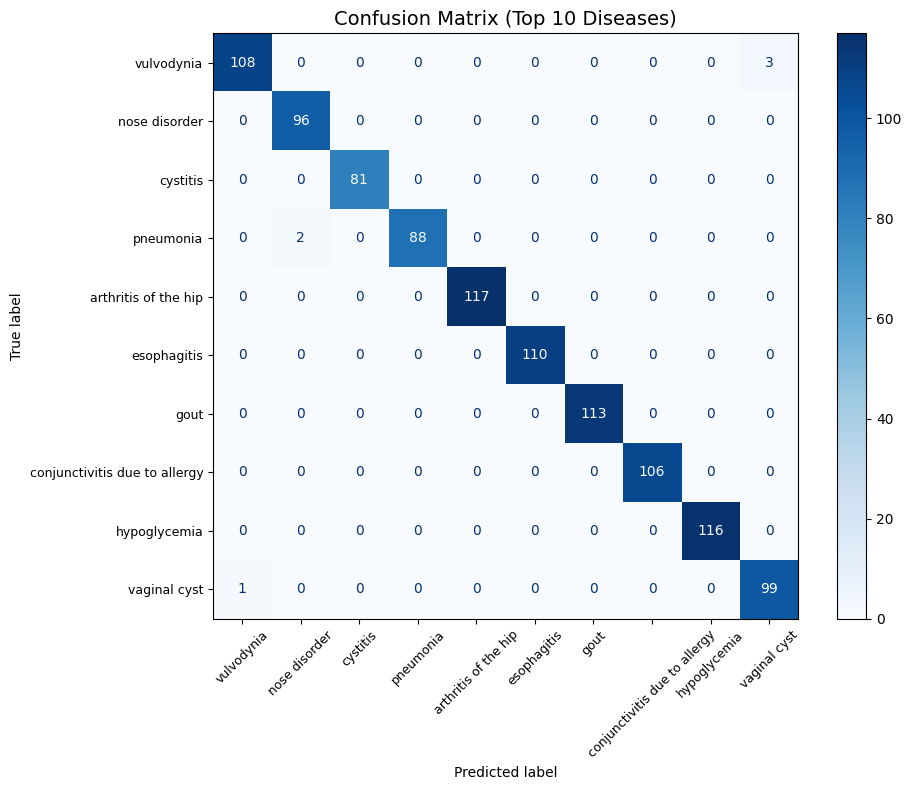

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

preds = trainer.predict(val_ds)
y_true = y_val
y_pred = np.argmax(preds.predictions, axis=1)

# 🔽 Use TOP 10 instead of 20
top_labels = pd.Series(y_true).value_counts().head(10).index.tolist()

mask = np.isin(y_true, top_labels)
y_true_f = y_true[mask]
y_pred_f = y_pred[mask]

cm = confusion_matrix(y_true_f, y_pred_f, labels=top_labels)

fig, ax = plt.subplots(figsize=(10, 8))  # ⬅️ smaller fits Top-10 well

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.inverse_transform(top_labels)
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=True
)

ax.set_title("Confusion Matrix (Top 10 Diseases)", fontsize=14)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()


CELL 16: FINAL TEST SET EVALUATION

In [ ]:
test_metrics = trainer.evaluate(test_ds)

print("📊 TEST RESULTS")
print("Accuracy:", round(test_metrics["eval_accuracy"]*100, 2), "%")
print("F1 Score:", round(test_metrics["eval_f1"], 4))

📊 TEST RESULTS
Accuracy: 85.55 %
F1 Score: 0.8403


CELL 17: SAVE MODEL (SINGLE SOURCE OF TRUTH)

In [ ]:
MODEL_DIR = "./disease_classifier"

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print("✅ Model saved to", MODEL_DIR)

✅ Model saved to ./disease_classifier


CELL 18: INFERENCE UTILITIES

In [ ]:
inference_model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
inference_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
label_encoder = joblib.load("label_encoder.pkl")

def predict_top_k(text, k=3):
    inputs = inference_tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=256
    ).to(device)

    with torch.no_grad():
        logits = inference_model(**inputs).logits[0]

    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    top = probs.argsort()[::-1][:k]

    return [(label_encoder.inverse_transform([i])[0], probs[i]) for i in top]

CELL 19: ROBUST SYMPTOM EXTRACTION (TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

symptoms_list = joblib.load("symptoms_list.pkl")

vectorizer = TfidfVectorizer(ngram_range=(1,3))
symptom_vecs = vectorizer.fit_transform(symptoms_list)

def extract_symptoms(text, thresh=0.15):
    text = re.sub(r"[^a-zA-Z ]", " ", text.lower())
    vec = vectorizer.transform([text])
    sims = cosine_similarity(vec, symptom_vecs)[0]

    idx = np.where(sims > thresh)[0]
    return [symptoms_list[i] for i in idx][:10]

CELL 20A : LOAD QWEN-3B (FROZEN, INFERENCE ONLY)

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

QWEN_MODEL = "Qwen/Qwen2.5-3B-Instruct"

qwen_tokenizer = AutoTokenizer.from_pretrained(QWEN_MODEL)

qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL,
    device_map="auto",
    load_in_4bit=True,
    torch_dtype=torch.float16
)

qwen_model.eval()

print("✅ Qwen-3B loaded")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Qwen-3B loaded


CELL 20B — QWEN RESPONSE GENERATOR (CONTROLLED)

In [ ]:
def qwen_explain(symptoms, predictions):
    prompt = f"""
Symptoms detected:
{symptoms}

Model predictions:
{predictions}
"""

    inputs = qwen_tokenizer(prompt, return_tensors="pt").to(qwen_model.device)

    with torch.no_grad():
        output = qwen_model.generate(
            **inputs,
            max_new_tokens=250,
            temperature=0.4,
            do_sample=True
        )

    return qwen_tokenizer.decode(output[0], skip_special_tokens=True)

CELL 20C — FORMAT CLASSIFIER OUTPUT (IMPORTANT)

In [ ]:
def format_predictions(preds):
    return "\n".join(
        [f"{disease} ({prob*100:.1f}%)" for disease, prob in preds]
    )

CELL 20D — ✅ REPLACED MEDICAL CHATBOT (FINAL)

In [ ]:
class MedicalChatbot:
    def __init__(self):
        self.memory = set()

    def process(self, user_text):
        found = extract_symptoms(user_text)
        self.memory.update(found)

        # HARD GUARD
        if not self.memory:
            return (
                "I’m here to help.\n"
                "Please describe your symptoms such as fever, pain, cough, or fatigue."
            )

        symptom_text = ", ".join(self.memory)
        preds = predict_top_k(symptom_text, k=5)

        # Confidence guard
        if preds[0][1] < 0.25:
            return (
                "I need a bit more information to be confident.\n"
                "Could you describe any additional symptoms?"
            )

        formatted_preds = format_predictions(preds)

        # 🔥 QWEN ONLY HERE
        response = qwen_explain(
            symptoms=symptom_text,
            predictions=formatted_preds
        )

        return response

QUICK SANITY TEST (OPTIONAL)

In [ ]:
bot = MedicalChatbot()
print(bot.process("I have shortness of breath, chest tightness, shortness of breath, anxiety and nervousness"))


Symptoms detected:
shortness of breath, chest tightness, anxiety and nervousness

Model predictions:
panic attack (90.3%)
panic disorder (0.6%)
adrenal adenoma (0.3%)
coronary atherosclerosis (0.2%)
acute respiratory distress syndrome (ards) (0.2%)
neuromuscular disease (0.1%)
severe acute respiratory failure (sarf) (0.1%)
myocardial infarction (mi) (0.1%)

Assistant: Based on the symptoms you described, the model predicts that a panic attack is the most likely condition, with a probability of 90.3%. This is supported by the fact that your symptoms—shortness of breath, chest tightness, anxiety, and nervousness—are common symptoms associated with panic attacks.

The other conditions listed are less likely based on these symptoms, though they could still be possible in certain contexts. For example, severe acute respiratory failure (SARF) might cause similar symptoms but would typically have additional symptoms or signs not mentioned here. Similarly, myocardial infarction (MI) or corona